In [2]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# go_df=pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/circos-plot/segdup-feature/segdup_genes_hotspots.tsv", sep="\t", index_col=0)
# go_df=pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/segdup-investigation/segdup_genes_hotspots_bpLevel_elemDecomposition.tsv", sep="\t", index_col=0)
# go_df=pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/segdup-investigation/segdup_genes_hotspots_bpLevel_seqRemoved_top95percentile.tsv", sep="\t", index_col=0)
go_df=pd.read_csv("segdup_genes_hotspots_80percLength.tsv", sep="\t", index_col=0)

# background_df=pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/segdup-investigation/segdup_genes_hotspots_bpLevel.tsv", sep="\t", index_col=0)
background_df = pd.read_csv("hifiasm_gene_segDup_overlapInfo_081726.tsv", sep="\t")

In [6]:

print(background_df.shape)

(26273, 14)


In [7]:
print(go_df.shape)

(1271, 14)


In [8]:
search_terms = ["LARP7", "CCT4", "CCT7","MEPCE"]
pattern = "|".join(search_terms)

# This version handles missing values and is case-insensitive
filtered_go_df = go_df[
    go_df["gene"].str.contains(pattern, case=False, na=False)
]

filtered_go_df

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
275,10868,chrX,AUGUSTUS,gene,51504001,51505395,.,+,.,ID=gene-Larp7-dl5;Name=Larp7-dl5;origin=de_novo,LARP7-DL5,51504000,51505395,True
1135,41182,chrY,AUGUSTUS,gene,40377977,40379801,.,+,.,ID=gene-Cct4-dl2;Name=Cct4-dl2;origin=de_novo,CCT4-DL2,40377976,40379801,True
3943,173619,chr2,AUGUSTUS,gene,87958356,87959257,.,-,.,ID=gene-Larp7-dl4;Name=Larp7-dl4;origin=de_novo,LARP7-DL4,87958355,87959257,True
4330,191605,chr3,AUGUSTUS,gene,15271858,15273642,.,-,.,ID=gene-Cct7-dl3;Name=Cct7-dl3;origin=de_novo,CCT7-DL3,15271857,15273642,True
17423,796506,chr16,AUGUSTUS,gene,41417267,41419525,.,-,.,ID=gene-Larp7-dl2;Name=Larp7-dl2;origin=de_novo,LARP7-DL2,41417266,41419525,True


In [9]:
gene_list = go_df["gene"]
cleaned = gene_list.str.replace(r"-(?:DL|RL|L)\d+$", "", regex=True)
unique_genes=cleaned.unique()
print(len(unique_genes))
unique_genes

background_list = background_df["gene"]
cleaned = background_list.str.replace(r"-(?:DL|RL|L)\d+$", "", regex=True)
background_genes=cleaned.unique()
print(len(background_genes))

1086
24092


In [10]:
import requests

# Download the latest human GO Biological Process GMT
url = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=GO_Biological_Process_2025"
response = requests.get(url)
with open("human_GO_bp_2025.gmt", "w") as f:
    f.write(response.text)

In [11]:
# Filter out genes containing "LOC"
filtered_genes = unique_genes[~pd.Series(unique_genes).str.contains("LOC", na=False)]
filtered_genes = np.unique(filtered_genes)
print(len(filtered_genes))
filtered_genes


# Filter out genes containing "LOC"
background_genes = background_genes[~pd.Series(background_genes).str.contains("LOC", na=False)]
background_genes = np.unique(background_genes)
print(len(background_genes))

## Put this in metascape
filtered_genes

469
17235


array(['AADAC', 'ABCG2', 'ACAA2', 'ACAD10', 'ACO1', 'ADAM20', 'ADAM3',
       'ADAMTSL1', 'ADGRD1', 'ADH7', 'AIF1L', 'AKR1B10', 'AKR1B8',
       'ALDH1A1', 'ALOX12E', 'AMD1', 'AMY1', 'AMY2', 'APOL2', 'APOL3',
       'AQR', 'ARF4', 'ARHGAP30', 'ARMC3', 'ARPC5', 'ASNS', 'ATG12',
       'BBS9', 'BDP1', 'BIRC2', 'BMP8B', 'BMPER', 'BNIP3', 'BOLL', 'BRK1',
       'C3ORF20', 'CASP1', 'CASP2', 'CCDC14', 'CCDC174', 'CCL3', 'CCL3L1',
       'CCL3L3', 'CCL4', 'CCNB1', 'CCT3', 'CCT4', 'CCT7', 'CD1B2', 'CD33',
       'CEACAM1', 'CEACAM21', 'CEL', 'CENPI', 'CEP78', 'CES1', 'CES2E',
       'CFAP206', 'CFAP54', 'CH1', 'CHCHD2', 'CHD2', 'CHFR', 'CIAO2B',
       'CLCA4', 'CMC1', 'CNOT10', 'COIL', 'COPG2', 'COPS4', 'COX15',
       'CPD', 'CPM', 'CRLF3', 'CSDE1', 'CSE1L', 'CSF2RB', 'CST3',
       'CTAGE9', 'CTRB1', 'CUL2', 'CUNH14ORF39', 'CUNH3ORF20',
       'CUNH4ORF17', 'CXCL17', 'CYP11B1', 'CYP2A6', 'CYP2B4', 'CYP2C25',
       'CYP2D16', 'CYP2D4', 'CYP2J2', 'CYP3A4', 'CYTH3', 'DARS', 'DDX11',
       'D

In [12]:
list(filtered_genes)

['AADAC',
 'ABCG2',
 'ACAA2',
 'ACAD10',
 'ACO1',
 'ADAM20',
 'ADAM3',
 'ADAMTSL1',
 'ADGRD1',
 'ADH7',
 'AIF1L',
 'AKR1B10',
 'AKR1B8',
 'ALDH1A1',
 'ALOX12E',
 'AMD1',
 'AMY1',
 'AMY2',
 'APOL2',
 'APOL3',
 'AQR',
 'ARF4',
 'ARHGAP30',
 'ARMC3',
 'ARPC5',
 'ASNS',
 'ATG12',
 'BBS9',
 'BDP1',
 'BIRC2',
 'BMP8B',
 'BMPER',
 'BNIP3',
 'BOLL',
 'BRK1',
 'C3ORF20',
 'CASP1',
 'CASP2',
 'CCDC14',
 'CCDC174',
 'CCL3',
 'CCL3L1',
 'CCL3L3',
 'CCL4',
 'CCNB1',
 'CCT3',
 'CCT4',
 'CCT7',
 'CD1B2',
 'CD33',
 'CEACAM1',
 'CEACAM21',
 'CEL',
 'CENPI',
 'CEP78',
 'CES1',
 'CES2E',
 'CFAP206',
 'CFAP54',
 'CH1',
 'CHCHD2',
 'CHD2',
 'CHFR',
 'CIAO2B',
 'CLCA4',
 'CMC1',
 'CNOT10',
 'COIL',
 'COPG2',
 'COPS4',
 'COX15',
 'CPD',
 'CPM',
 'CRLF3',
 'CSDE1',
 'CSE1L',
 'CSF2RB',
 'CST3',
 'CTAGE9',
 'CTRB1',
 'CUL2',
 'CUNH14ORF39',
 'CUNH3ORF20',
 'CUNH4ORF17',
 'CXCL17',
 'CYP11B1',
 'CYP2A6',
 'CYP2B4',
 'CYP2C25',
 'CYP2D16',
 'CYP2D4',
 'CYP2J2',
 'CYP3A4',
 'CYTH3',
 'DARS',
 'DDX11',
 'DDX50',
 

<Figure size 1000x800 with 0 Axes>

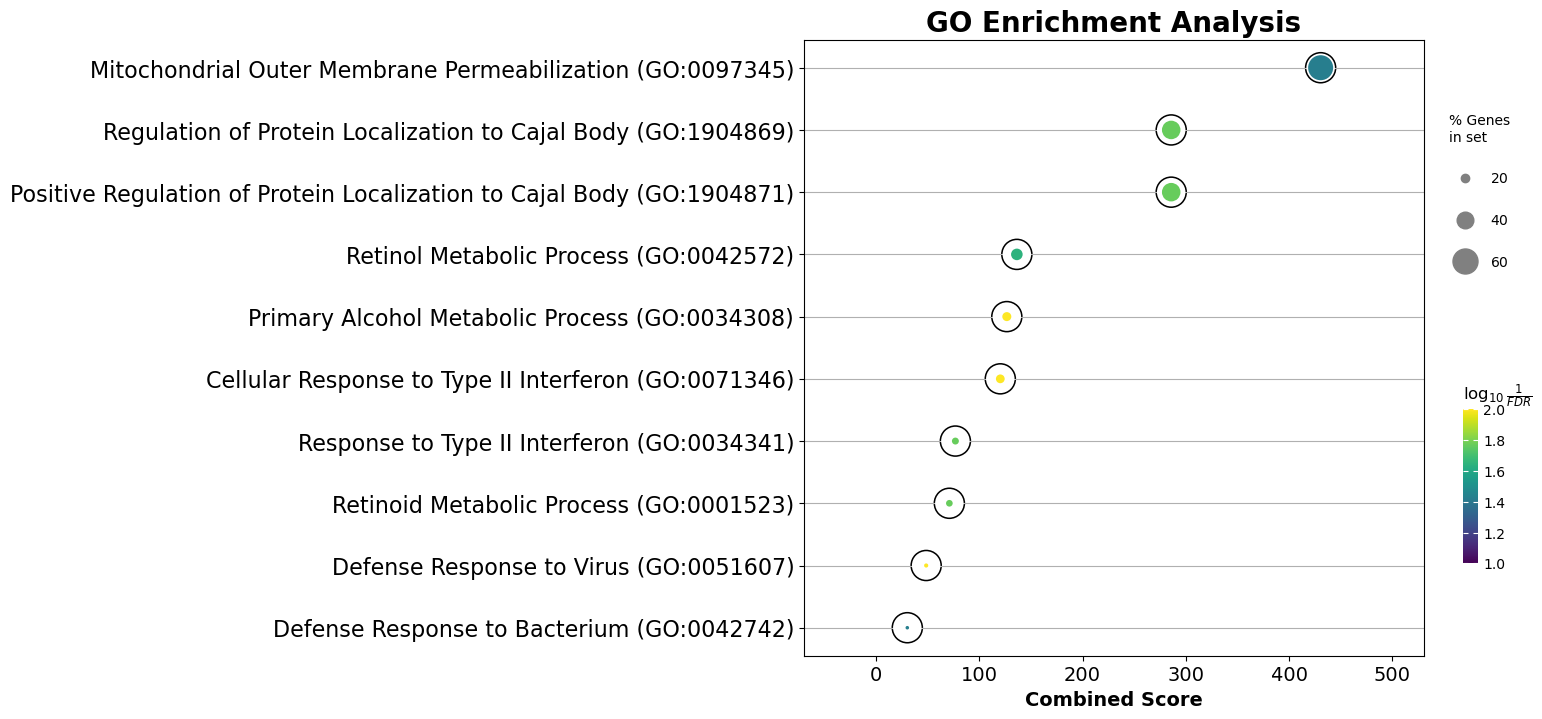

In [13]:
# Perform GO enrichment analysis
go_results  = gp.enrichr(
    gene_list=list(filtered_genes),  # Your converted gene list
    gene_sets="human_GO_bp_2025.gmt",     # Custom GMT file
    background=list(background_genes),  # Now this will be used!
    outdir=None
)

go_df = go_results.results
go_df.to_csv('go_enrichment_results_segdup_hotspot_seqRemoved_80percLength.csv', index=False)

# Plot top terms
plt.figure(figsize=(10, 8))
gp.dotplot(go_results.results, 
           title='GO Enrichment Analysis',
           cutoff=0.05,  # p-value cutoff
           top_term=10,  # show top 10 terms
           fontsize = 12,
           figsize=(10, 8),
           show_ring=True,
           cmap='viridis')
plt.savefig('go_enrichment_plot_segdup_hotspot_seqRemoved_80percLength.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

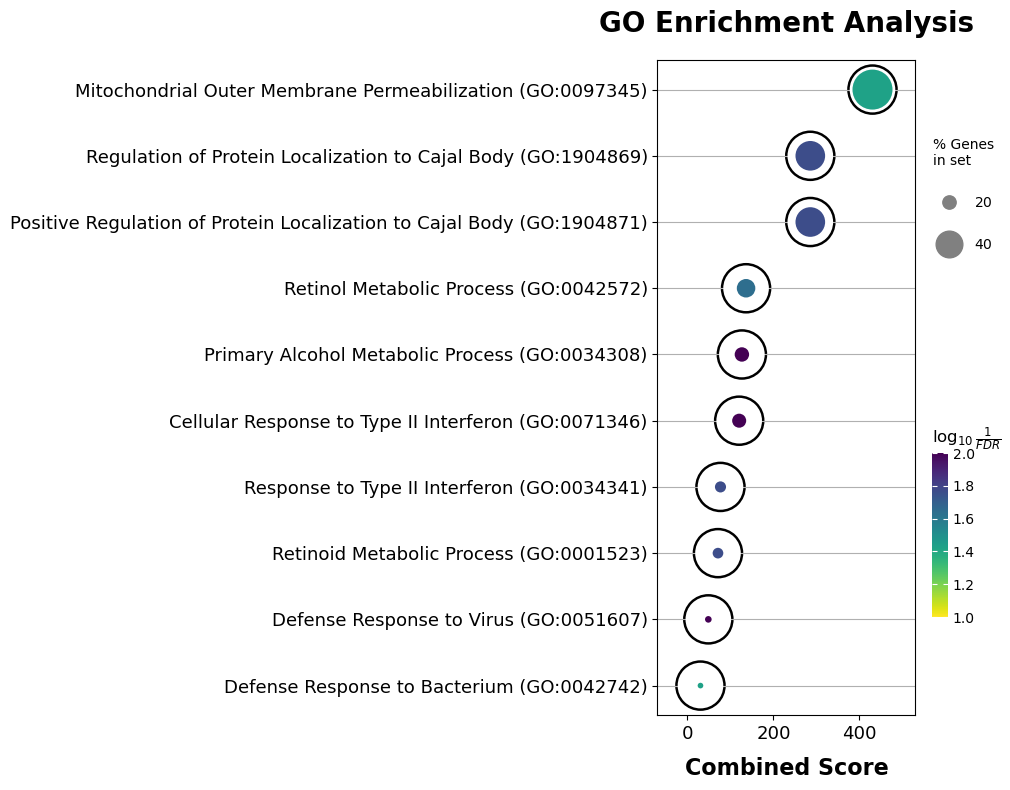

In [14]:
import matplotlib.pyplot as plt
import gseapy as gp

# Perform GO enrichment analysis
go_results = gp.enrichr(
    gene_list=list(filtered_genes),
    gene_sets="human_GO_bp_2025.gmt",
    background=list(background_genes),
    outdir=None
)

# Save results
go_df = go_results.results
# go_df.to_csv('go_enrichment_results_segdup_hotspot.csv', index=False)

# --- Publication-quality plot ---
plt.figure(figsize=(12, 6))

ax = gp.dotplot(
    go_results.results,
    title='GO Enrichment Analysis',
    cutoff=0.05,
    top_term=10,
    figsize=(10, 8),
    cmap='viridis_r',          # inverted colormap for contrast
    show_ring=True,
    marker='o',
    size=8,                    # increase circle size
    linewidth=1.2,             # thicker outline around circles
    edgecolor='black',         # black border for visibility
    alpha=0.9,                 # slightly transparent for overlapping
    fontsize=14,               # increase text size
)

# --- Further aesthetic adjustments ---
plt.title('GO Enrichment Analysis', fontsize=20, weight='bold', pad=20)
plt.xlabel('Combined Score', fontsize=16, labelpad=10)
plt.ylabel('', fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# plt.grid(False)

# Tight layout and high-res save
plt.tight_layout()
# plt.savefig('go_enrichment_plot_segdup_hotspot_pubready.png', dpi=600, bbox_inches='tight')
plt.show()

In [15]:
ax.get_yticklabels()

[Text(0, 0, 'Defense Response to Bacterium (GO:0042742)'),
 Text(0, 1, 'Defense Response to Virus (GO:0051607)'),
 Text(0, 2, 'Retinoid Metabolic Process (GO:0001523)'),
 Text(0, 3, 'Response to Type II Interferon (GO:0034341)'),
 Text(0, 4, 'Cellular Response to Type II Interferon (GO:0071346)'),
 Text(0, 5, 'Primary Alcohol Metabolic Process (GO:0034308)'),
 Text(0, 6, 'Retinol Metabolic Process (GO:0042572)'),
 Text(0, 7, 'Positive Regulation of Protein Localization to Cajal Body (GO:1904871)'),
 Text(0, 8, 'Regulation of Protein Localization to Cajal Body (GO:1904869)'),
 Text(0, 9, 'Mitochondrial Outer Membrane Permeabilization (GO:0097345)')]

In [16]:
import textwrap

# Wrap long GO term labels to multiple lines
new_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
    wrapped = "\n".join(textwrap.wrap(text, width=30))  # wrap every 30 characters
    new_labels.append(wrapped)
ax.set_yticklabels(new_labels)

/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_3999917/2655881135.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(new_labels)


[Text(0, 0, 'Defense Response to Bacterium\n(GO:0042742)'),
 Text(0, 1, 'Defense Response to Virus\n(GO:0051607)'),
 Text(0, 2, 'Retinoid Metabolic Process\n(GO:0001523)'),
 Text(0, 3, 'Response to Type II Interferon\n(GO:0034341)'),
 Text(0, 4, 'Cellular Response to Type II\nInterferon (GO:0071346)'),
 Text(0, 5, 'Primary Alcohol Metabolic\nProcess (GO:0034308)'),
 Text(0, 6, 'Retinol Metabolic Process\n(GO:0042572)'),
 Text(0, 7, 'Positive Regulation of Protein\nLocalization to Cajal Body\n(GO:1904871)'),
 Text(0, 8, 'Regulation of Protein\nLocalization to Cajal Body\n(GO:1904869)'),
 Text(0, 9, 'Mitochondrial Outer Membrane\nPermeabilization (GO:0097345)')]

In [17]:
go_results.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,human_GO_bp_2025.gmt,'De Novo' Post-Translational Protein Folding (...,3/34,0.064349,0.560554,3.986066,10.935488,CCT3;CCT4;CCT7
1,human_GO_bp_2025.gmt,"+ Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...",2/4,0.004275,0.214785,35.859893,195.613116,LGALS9;IFNG
2,human_GO_bp_2025.gmt,+ Reg of Mt Membrane Permeability Inv in Apopt...,3/7,0.000646,0.074461,27.947481,205.273296,VDAC2;BNIP3;RHOT1
3,human_GO_bp_2025.gmt,+ Reg of Mt Outer Membrane Permeabilization In...,1/7,0.175649,0.636414,8.255726,14.358939,SIVA1
4,human_GO_bp_2025.gmt,+ Reg of Myeloid Leukocyte Cytokine Production...,1/13,0.301476,0.656543,4.291441,5.145714,PLCG2
...,...,...,...,...,...,...,...,...
1955,human_GO_bp_2025.gmt,tRNA Decay (GO:0016078),1/5,0.128868,0.634942,11.926361,24.436688,SLFN13
1956,human_GO_bp_2025.gmt,tRNA Metabolic Process (GO:0006399),2/21,0.110548,0.634942,4.592760,10.114653,SLFN13;LAGE3
1957,human_GO_bp_2025.gmt,tRNA Modification (GO:0006400),1/67,0.843088,0.905950,0.804062,0.137240,QTRT2
1958,human_GO_bp_2025.gmt,tRNA Threonylcarbamoyladenosine Metabolic Proc...,1/8,0.198090,0.643970,7.154536,11.583437,LAGE3


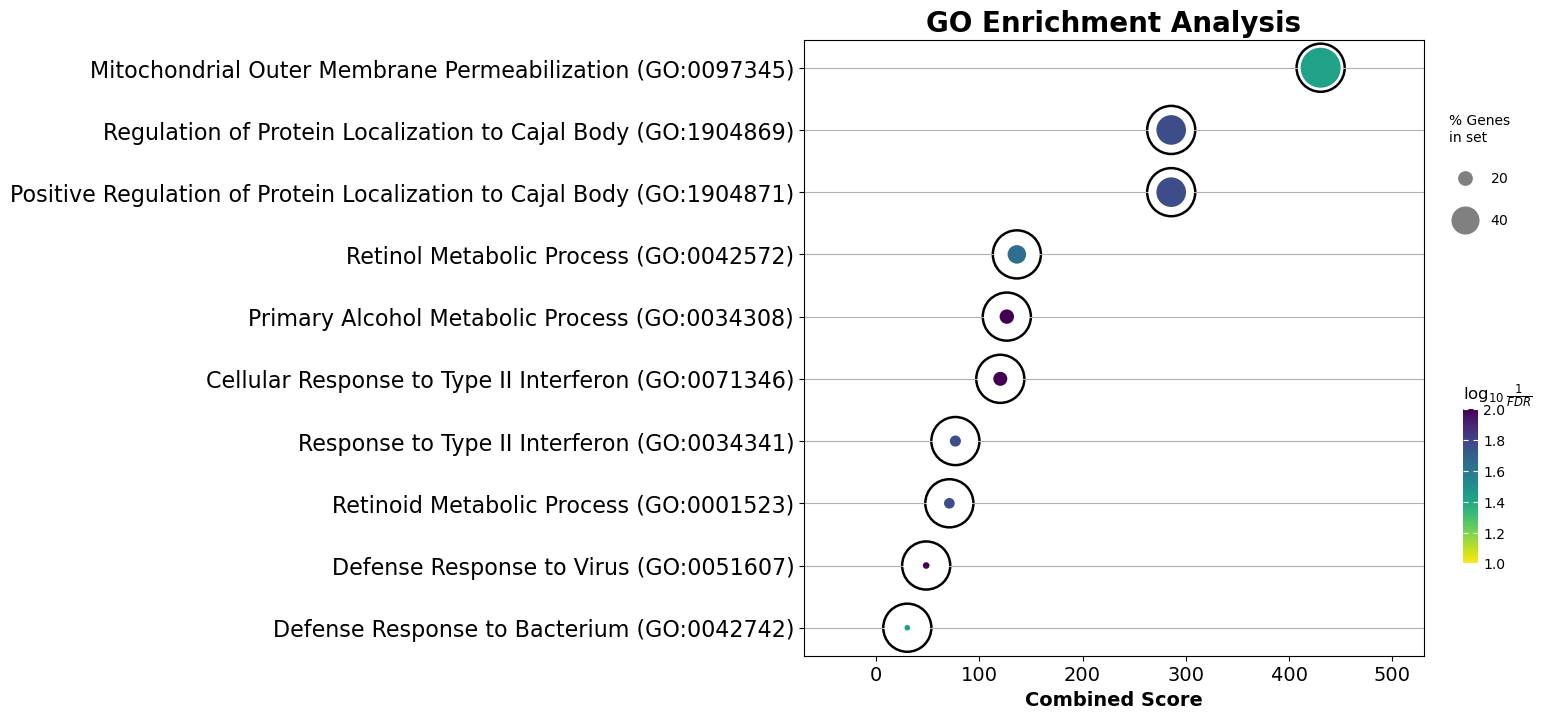

In [18]:
ax = gp.dotplot(
    go_results.results,
    title='GO Enrichment Analysis',
    cutoff=0.05,
    top_term=10,
    figsize=(10, 8),
    cmap='viridis_r',          # inverted colormap for contrast
    show_ring=True,
    marker='o',
    size=8,                    # increase circle size
    linewidth=1.2,             # thicker outline around circles
    edgecolor='black',         # black border for visibility
    alpha=0.9,                 # slightly transparent for overlapping
    fontsize=14,               # increase text size
)

/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_3999917/2582799899.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(new_labels, fontsize=16, fontweight='bold')


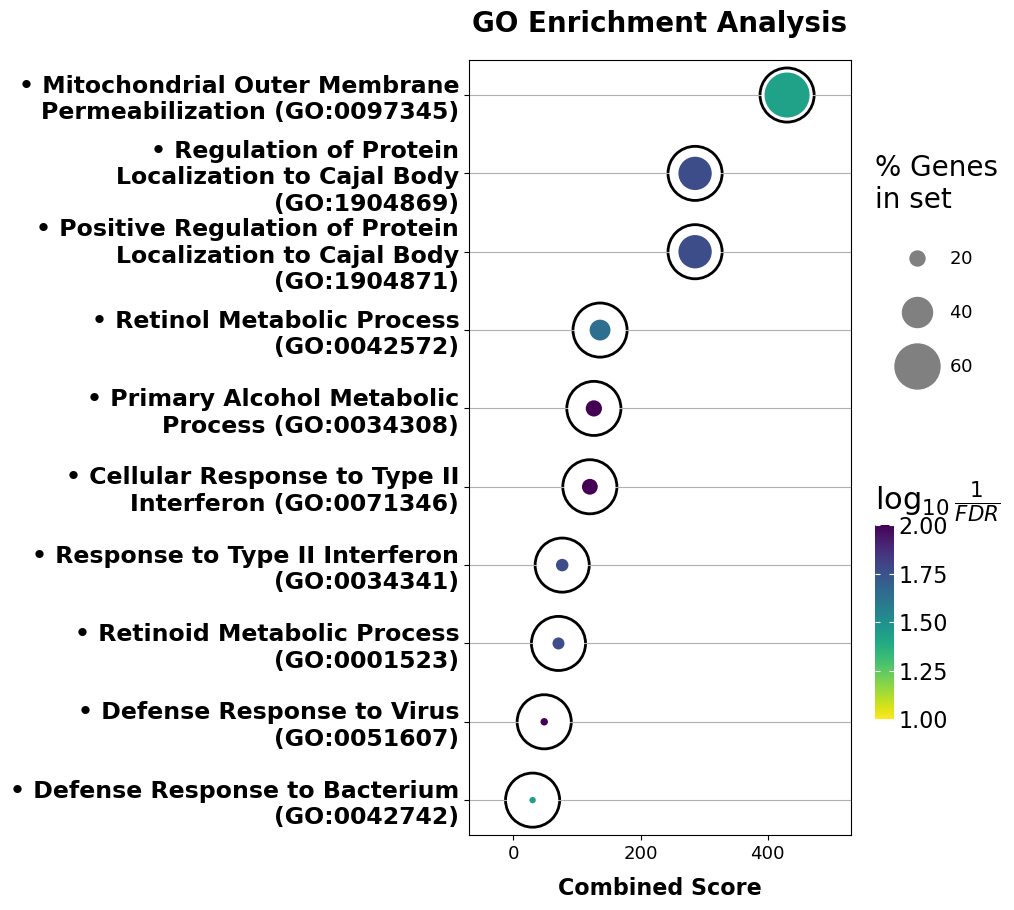

In [36]:

# Set global font sizes before plotting
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 13,
})

ax = gp.dotplot(
    go_results.results,
    title='GO Enrichment Analysis',
    cutoff=0.05,
    top_term=10,
    figsize=(10, 9.5),
    cmap='viridis_r',
    show_ring=True,
    marker='o',
    size=9,
    linewidth=1.2,
    edgecolor='black',
    alpha=0.9,
    fontsize=14,
)

# --- Add bullet points + wrap long GO term labels ---
new_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
    # Wrap every 30 characters and add a bullet point at the start
    wrapped = "\n".join(textwrap.wrap(text, width=30))
    wrapped = f"• {wrapped}"
    new_labels.append(wrapped)
ax.set_yticklabels(new_labels, fontsize=16, fontweight='bold')

# --- Further aesthetic adjustments ---
plt.title('GO Enrichment Analysis', fontsize=20, weight='bold', pad=20)
plt.xlabel('Combined Score', fontsize=16, labelpad=10)
plt.xticks(fontsize=13)
plt.yticks(fontsize=17, fontweight='bold')
# cbar = ax.collections[0].colorbar
# cbar.ax.tick_params(labelsize=14)  # <- controls the numeric tick font size

plt.tight_layout()
plt.savefig('go_enrichment_plot_segdup_hotspot_seqRemoved_80percLength_pubready.png', dpi=600, bbox_inches='tight')
plt.show()

In [45]:
go_df["numGene"] = go_df["Overlap"].astype(str).str.split("/").str[0]


In [46]:
go_df[go_df["Term"].str.contains("Defense")]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,GO_ID,numGene
272,human_GO_bp_2025.gmt,Defense Response to Bacterium (GO:0042742),14/165,0.000171,0.037343,3.491246,30.272912,LYZ;GSDMC;S100A8;RNASE1;GBP6;RNASE6;CASP1;GBP1...,GO:0042742,14
273,human_GO_bp_2025.gmt,Defense Response to Fungus (GO:0050832),2/25,0.147338,0.634942,3.810104,7.296454,PLCG2;S100A8,GO:0050832,2
274,human_GO_bp_2025.gmt,Defense Response to Gram-negative Bacterium (G...,3/58,0.209327,0.643970,2.259118,3.532940,MPEG1;RNASE6;LYZ,GO:0050829,3
275,human_GO_bp_2025.gmt,Defense Response to Gram-positive Bacterium (G...,6/66,0.009015,0.292791,3.872520,18.235256,LYZ;RNASE1;GBP6;RNASE6;MPEG1;RNASE9,GO:0050830,6
276,human_GO_bp_2025.gmt,Defense Response to Protozoan (GO:0042832),2/10,0.028774,0.433398,10.543253,37.410438,GBP6;GBP1,GO:0042832,2
277,human_GO_bp_2025.gmt,Defense Response to Symbiont (GO:0140546),1/6,0.152580,0.634942,9.757349,18.344433,LYZ,GO:0140546,1
278,human_GO_bp_2025.gmt,Defense Response to Virus (GO:0051607),16/161,0.000008,0.005527,4.156367,48.547562,SLFN13;IFNL3;EXOSC5;GBP5;RNASE1;TRIM8;RNASE6;C...,GO:0051607,16
653,human_GO_bp_2025.gmt,Negative Regulation of Defense Response (GO:00...,5/114,0.199476,0.643970,1.801245,2.903719,PTPN2;ATG12;CXCL17;DTX4;FPR2,GO:0031348,5
1006,human_GO_bp_2025.gmt,Positive Regulation of Defense Response (GO:00...,7/119,0.044012,0.511919,2.400649,7.497922,LILRA5;GBP5;S100A8;CASP1;CCL3;IFNG;FPR2,GO:0031349,7
1440,human_GO_bp_2025.gmt,Regulation of Defense Response (GO:0031347),4/91,0.235492,0.643970,1.842756,2.664768,SAMHD1;BIRC2;CASP1;XIAP,GO:0031347,4


In [48]:
go_df.sort_values("Combined Score").tail(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,GO_ID,numGene
1,human_GO_bp_2025.gmt,"+ Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...",2/4,0.004275,0.214785,35.859893,195.613116,LGALS9;IFNG,GO:0032831,2
1568,human_GO_bp_2025.gmt,Regulation of Natural Killer Cell Chemotaxis (...,2/4,0.004275,0.214785,35.859893,195.613116,CCL3;CCL4,GO:2000501,2
2,human_GO_bp_2025.gmt,+ Reg of Mt Membrane Permeability Inv in Apopt...,3/7,0.000646,0.074461,27.947481,205.273296,VDAC2;BNIP3;RHOT1,GO:1902110,3
220,human_GO_bp_2025.gmt,Chaperone Mediated Protein Folding Independent...,3/7,0.000646,0.074461,27.947481,205.273296,CCT3;CCT4;CCT7,GO:0051086,3
1141,human_GO_bp_2025.gmt,Positive Regulation of Protein Localization to...,4/9,0.000061,0.017134,29.460697,285.813186,CCT3;CCT4;LARP7;CCT7,GO:1904871,4
1610,human_GO_bp_2025.gmt,Regulation of Protein Localization to Cajal Bo...,4/9,0.000061,0.017134,29.460697,285.813186,CCT3;CCT4;LARP7;CCT7,GO:1904869,4
1242,human_GO_bp_2025.gmt,Protection From Natural Killer Cell Mediated C...,1/1,0.027212,0.433398,107.362860,386.945917,SERPINB9,GO:0042270,1
1893,human_GO_bp_2025.gmt,Type IIa Hypersensitivity (GO:0001794),1/1,0.027212,0.433398,107.362860,386.945917,FCGR2A,GO:0001794,1
55,human_GO_bp_2025.gmt,Antibody-Dependent Cellular Cytotoxicity (GO:0...,1/1,0.027212,0.433398,107.362860,386.945917,FCGR2A,GO:0001788,1
542,human_GO_bp_2025.gmt,Mitochondrial Outer Membrane Permeabilization ...,3/5,0.000192,0.037675,50.311468,430.509520,VDAC2;BNIP3;RHOT1,GO:0097345,3


In [49]:
go_df.sort_values("numGene").tail(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,GO_ID,numGene
967,human_GO_bp_2025.gmt,Positive Regulation of Cell Migration (GO:0030...,9/327,0.533661,0.729932,1.065395,0.669062,CCL3L1;RNASE1;TCAF2;CCL3;SERPINB3;SOD2;PLCG2;I...,GO:0030335,9
1811,human_GO_bp_2025.gmt,Small GTPase-mediated Signal Transduction (GO:...,9/179,0.056435,0.542217,2.008104,5.772632,USP50;RNASE1;GRB2;RALGDS;USP8;BRK1;NCKAP1;ARHG...,GO:0007264,9
1687,human_GO_bp_2025.gmt,Regulation of Translation (GO:0006417),9/194,0.083812,0.623125,1.844055,4.571749,CNOT10;DHFR;EIF5B;EIF4ENIF1;DDX6;GZMB;RPL26;SY...,GO:0006417,9
1278,human_GO_bp_2025.gmt,Protein Maturation (GO:0051604),9/148,0.020044,0.399661,2.458933,9.614056,CASP2;CPM;NAA16;CASP1;GZMB;KLK4;CIAO2B;GZMH;SDE2,GO:0051604,9
757,human_GO_bp_2025.gmt,Negative Regulation of Protein Metabolic Proce...,9/140,0.014449,0.345367,2.609781,11.057980,CNOT10;DHFR;SNX3;EIF4ENIF1;GZMB;CST3;DDX6;SERP...,GO:0051248,9
1032,human_GO_bp_2025.gmt,Positive Regulation of Gene Expression (GO:001...,9/411,0.790885,0.868831,0.838747,0.196772,LGALS9;RHOXF1;GJA1;CCL3;RPS7;PLCG2;RPL26;IFNG;...,GO:0010628,9
645,human_GO_bp_2025.gmt,Negative Regulation of Cytokine Production (GO...,9/177,0.053291,0.536347,2.032183,5.958325,LILRA5;RNASE1;GBP1;LGALS9;CEACAM1;ATG12;CD33;S...,GO:0001818,9
1046,human_GO_bp_2025.gmt,Positive Regulation of Inflammatory Response (...,9/104,0.002120,0.143197,3.601350,22.170313,NUPR1;LILRA5;GBP5;GBP1;S100A8;CASP1;CCL3;PLCG2...,GO:0050729,9
248,human_GO_bp_2025.gmt,Cytoplasmic Translation (GO:0002181),9/93,0.000964,0.086282,4.072850,28.281922,RPL10A;RPL9;RPL35;RPL23A;RPL7;RPS7;RPL22;RPL26...,GO:0002181,9
1946,human_GO_bp_2025.gmt,rRNA Metabolic Process (GO:0016072),9/92,0.000892,0.086282,4.121874,28.943637,SLFN13;EXOSC5;SBDS;RPL7;SLFN12;RPS7;RPL26;RPS2...,GO:0016072,9


In [22]:
go_df[go_df["Term"].str.contains("Defense")]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
272,human_GO_bp_2025.gmt,Defense Response to Bacterium (GO:0042742),14/165,0.000171,0.037343,3.491246,30.272912,LYZ;GSDMC;S100A8;RNASE1;GBP6;RNASE6;CASP1;GBP1...
273,human_GO_bp_2025.gmt,Defense Response to Fungus (GO:0050832),2/25,0.147338,0.634942,3.810104,7.296454,PLCG2;S100A8
274,human_GO_bp_2025.gmt,Defense Response to Gram-negative Bacterium (G...,3/58,0.209327,0.643970,2.259118,3.532940,MPEG1;RNASE6;LYZ
275,human_GO_bp_2025.gmt,Defense Response to Gram-positive Bacterium (G...,6/66,0.009015,0.292791,3.872520,18.235256,LYZ;RNASE1;GBP6;RNASE6;MPEG1;RNASE9
276,human_GO_bp_2025.gmt,Defense Response to Protozoan (GO:0042832),2/10,0.028774,0.433398,10.543253,37.410438,GBP6;GBP1
277,human_GO_bp_2025.gmt,Defense Response to Symbiont (GO:0140546),1/6,0.152580,0.634942,9.757349,18.344433,LYZ
278,human_GO_bp_2025.gmt,Defense Response to Virus (GO:0051607),16/161,0.000008,0.005527,4.156367,48.547562,SLFN13;IFNL3;EXOSC5;GBP5;RNASE1;TRIM8;RNASE6;C...
653,human_GO_bp_2025.gmt,Negative Regulation of Defense Response (GO:00...,5/114,0.199476,0.643970,1.801245,2.903719,PTPN2;ATG12;CXCL17;DTX4;FPR2
1006,human_GO_bp_2025.gmt,Positive Regulation of Defense Response (GO:00...,7/119,0.044012,0.511919,2.400649,7.497922,LILRA5;GBP5;S100A8;CASP1;CCL3;IFNG;FPR2
1440,human_GO_bp_2025.gmt,Regulation of Defense Response (GO:0031347),4/91,0.235492,0.643970,1.842756,2.664768,SAMHD1;BIRC2;CASP1;XIAP


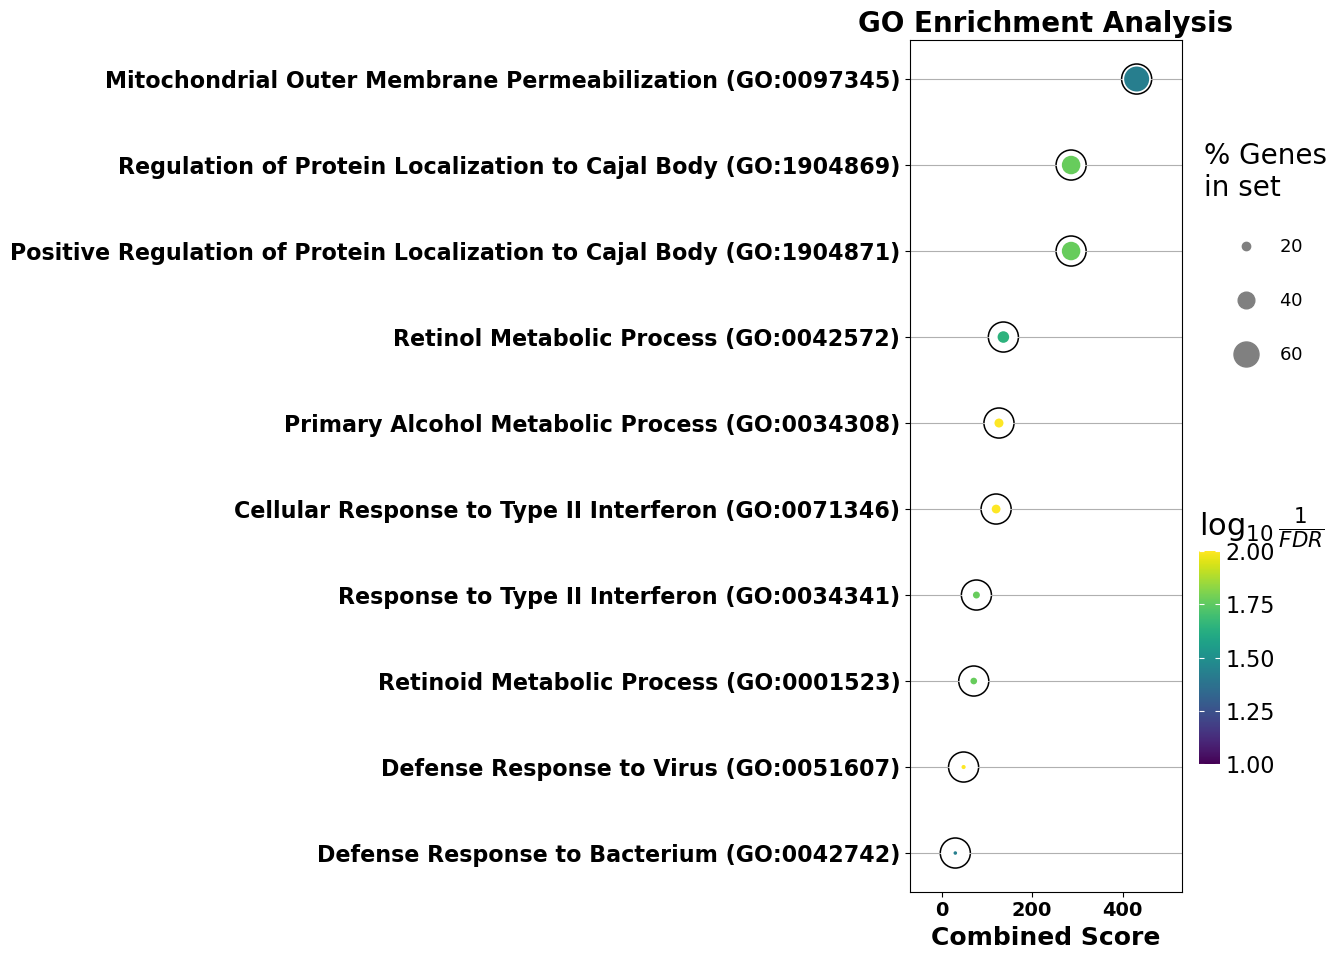

In [23]:
# plt.figure(figsize=(12, 8))
ax = gp.dotplot(
    go_results.results,
    title='GO Enrichment Analysis',
    cutoff=0.05,
    top_term=10,
    fontsize=16,          # Increase base font size
    figsize=(13, 10),
    show_ring=True,
    cmap='viridis'
)

# Make title, labels, and ticks more visible
# plt.title('GO Enrichment Analysis', fontsize=22, fontweight='bold',loc='left') 
plt.xlabel('Combined Score', fontsize=18, fontweight='bold')
plt.ylabel('', fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')

# Adjust colorbar label
# cbar = plt.gcf().axes[-1]  # last axis is colorbar
# cbar.tick_params(labelsize=12)
# cbar.set_ylabel(r'$\log_{10}\frac{1}{FDR}$', fontsize=24, fontweight='bold')

plt.tight_layout()
plt.savefig('go_enrichment_plot_segdup_hotspot_bold.svg', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
go_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,human_GO_bp_2025.gmt,'De Novo' Post-Translational Protein Folding (...,3/34,0.064349,0.560554,3.986066,10.935488,CCT3;CCT4;CCT7
1,human_GO_bp_2025.gmt,"+ Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...",2/4,0.004275,0.214785,35.859893,195.613116,LGALS9;IFNG
2,human_GO_bp_2025.gmt,+ Reg of Mt Membrane Permeability Inv in Apopt...,3/7,0.000646,0.074461,27.947481,205.273296,VDAC2;BNIP3;RHOT1
3,human_GO_bp_2025.gmt,+ Reg of Mt Outer Membrane Permeabilization In...,1/7,0.175649,0.636414,8.255726,14.358939,SIVA1
4,human_GO_bp_2025.gmt,+ Reg of Myeloid Leukocyte Cytokine Production...,1/13,0.301476,0.656543,4.291441,5.145714,PLCG2
...,...,...,...,...,...,...,...,...
1955,human_GO_bp_2025.gmt,tRNA Decay (GO:0016078),1/5,0.128868,0.634942,11.926361,24.436688,SLFN13
1956,human_GO_bp_2025.gmt,tRNA Metabolic Process (GO:0006399),2/21,0.110548,0.634942,4.592760,10.114653,SLFN13;LAGE3
1957,human_GO_bp_2025.gmt,tRNA Modification (GO:0006400),1/67,0.843088,0.905950,0.804062,0.137240,QTRT2
1958,human_GO_bp_2025.gmt,tRNA Threonylcarbamoyladenosine Metabolic Proc...,1/8,0.198090,0.643970,7.154536,11.583437,LAGE3


In [25]:
go_df["Term"]

0       'De Novo' Post-Translational Protein Folding (...
1       + Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...
2       + Reg of Mt Membrane Permeability Inv in Apopt...
3       + Reg of Mt Outer Membrane Permeabilization In...
4       + Reg of Myeloid Leukocyte Cytokine Production...
                              ...                        
1955                              tRNA Decay (GO:0016078)
1956                  tRNA Metabolic Process (GO:0006399)
1957                       tRNA Modification (GO:0006400)
1958    tRNA Threonylcarbamoyladenosine Metabolic Proc...
1959                          tRNA Transport (GO:0051031)
Name: Term, Length: 1960, dtype: object

In [26]:
go_df['GO_ID'] = go_df['Term'].str.extract(r'\((GO:\d+)\)')

In [27]:
go_df

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,GO_ID
0,human_GO_bp_2025.gmt,'De Novo' Post-Translational Protein Folding (...,3/34,0.064349,0.560554,3.986066,10.935488,CCT3;CCT4;CCT7,GO:0051084
1,human_GO_bp_2025.gmt,"+ Reg of CD4-+, CD25-+, Alpha-Beta Regulatory ...",2/4,0.004275,0.214785,35.859893,195.613116,LGALS9;IFNG,GO:0032831
2,human_GO_bp_2025.gmt,+ Reg of Mt Membrane Permeability Inv in Apopt...,3/7,0.000646,0.074461,27.947481,205.273296,VDAC2;BNIP3;RHOT1,GO:1902110
3,human_GO_bp_2025.gmt,+ Reg of Mt Outer Membrane Permeabilization In...,1/7,0.175649,0.636414,8.255726,14.358939,SIVA1,GO:1901030
4,human_GO_bp_2025.gmt,+ Reg of Myeloid Leukocyte Cytokine Production...,1/13,0.301476,0.656543,4.291441,5.145714,PLCG2,GO:0061081
...,...,...,...,...,...,...,...,...,...
1955,human_GO_bp_2025.gmt,tRNA Decay (GO:0016078),1/5,0.128868,0.634942,11.926361,24.436688,SLFN13,GO:0016078
1956,human_GO_bp_2025.gmt,tRNA Metabolic Process (GO:0006399),2/21,0.110548,0.634942,4.592760,10.114653,SLFN13;LAGE3,GO:0006399
1957,human_GO_bp_2025.gmt,tRNA Modification (GO:0006400),1/67,0.843088,0.905950,0.804062,0.137240,QTRT2,GO:0006400
1958,human_GO_bp_2025.gmt,tRNA Threonylcarbamoyladenosine Metabolic Proc...,1/8,0.198090,0.643970,7.154536,11.583437,LAGE3,GO:0070525


In [28]:
go_df.to_csv("GO_terms_segdup_hotspot_regions.tsv", sep="\t")

In [29]:
# Load genes
genes = pd.read_csv("/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/figure/segdup-investigation/hifiasm_gene_segDup_overlapInfo_092525.tsv", sep="\t")
genes["Start"] = genes["Start"].astype(int)
genes["End"] = genes["End"].astype(int)
genes["overlaps_dup"] = genes["overlaps_dup"].astype(bool)

In [30]:
genes[genes["gene"].str.contains("LARP7")]

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
275,10868,chrX,AUGUSTUS,gene,51504001,51505395,.,+,.,ID=gene-Larp7-dl5;Name=Larp7-dl5;origin=de_novo,LARP7-DL5,51504000,51505395,True
1513,59540,chr1,AUGUSTUS,gene,15814635,15815186,.,-,.,ID=gene-Larp7-dl1;Name=Larp7-dl1;origin=de_novo,LARP7-DL1,15814634,15815186,True
2174,100938,chr1,Liftoff,gene,93499047,93522497,.,-,.,ID=gene-Larp7;Dbxref=GeneID:101569408;Name=Lar...,LARP7,93499046,93522497,True
3943,173619,chr2,AUGUSTUS,gene,87958356,87959257,.,-,.,ID=gene-Larp7-dl4;Name=Larp7-dl4;origin=de_novo,LARP7-DL4,87958355,87959257,True
17423,796506,chr16,AUGUSTUS,gene,41417267,41419525,.,-,.,ID=gene-Larp7-dl2;Name=Larp7-dl2;origin=de_novo,LARP7-DL2,41417266,41419525,True
18591,842950,chr17,AUGUSTUS,gene,62111269,62111820,.,-,.,ID=gene-Larp7-dl3;Name=Larp7-dl3;origin=de_novo,LARP7-DL3,62111268,62111820,True


In [31]:
# genes[genes["gene"]=="CCT7"]
genes[genes["gene"].str.contains("CCT7")]

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
2319,106818,chr1,Liftoff,gene,122150133,122151501,.,+,.,ID=gene-Cct7-l1;Dbxref=GeneID:101582363;Name=C...,CCT7-L1,122150132,122151501,True
4330,191605,chr3,AUGUSTUS,gene,15271858,15273642,.,-,.,ID=gene-Cct7-dl3;Name=Cct7-dl3;origin=de_novo,CCT7-DL3,15271857,15273642,True
5772,254724,chr3,AUGUSTUS,gene,144006211,144007836,.,-,.,ID=gene-Cct7-dl4;Name=Cct7-dl4;origin=de_novo,CCT7-DL4,144006210,144007836,True
11514,506118,chr8,Liftoff,gene,95017378,95040244,.,-,.,ID=gene-Cct7-l2;Dbxref=GeneID:111814130;Name=C...,CCT7-L2,95017377,95040244,True
12316,552502,chr9,AUGUSTUS,gene,88499444,88501220,.,+,.,ID=gene-Cct7-dl5;Name=Cct7-dl5;origin=de_novo,CCT7-DL5,88499443,88501220,True
14749,678588,chr13,AUGUSTUS,gene,49716936,49718161,.,-,.,ID=gene-Cct7-dl1;Name=Cct7-dl1;origin=de_novo,CCT7-DL1,49716935,49718161,True
19417,880169,chr18,GeneMark.hmm3,gene,65319235,65320341,.,+,.,ID=gene-Cct7-dl2;Name=Cct7-dl2;origin=de_novo,CCT7-DL2,65319234,65320341,True
22894,1051290,chr22,Liftoff,gene,27804214,27826907,.,-,.,ID=gene-Cct7;Dbxref=GeneID:101563270;Name=Cct7...,CCT7,27804213,27826907,True


In [32]:
genes[genes["gene"].str.contains("CCT4")]

,Unnamed: 0,Chromosome,source,type,Gene Start,Gene End,score,Strand,phase,attributes,gene,Start,End,overlaps_dup
1135,41182,chrY,AUGUSTUS,gene,40377977,40379801,.,+,.,ID=gene-Cct4-dl2;Name=Cct4-dl2;origin=de_novo,CCT4-DL2,40377976,40379801,True
19538,884746,chr18,gmst,gene,83873284,83875084,.,+,.,ID=gene-Cct4-dl1;Name=Cct4-dl1;origin=de_novo,CCT4-DL1,83873283,83875084,True
23006,1056828,chr22,Liftoff,gene,39392292,39414603,.,+,.,ID=gene-Cct4;Dbxref=GeneID:101570839;Name=Cct4...,CCT4,39392291,39414603,True
